# J3 matin — Visualiser selon la question
**9h00–12h30 · Programmation en Python · Mastère 1 Data & IA**

Quel graphique permet réellement de répondre à la question posée ?

Un graphique utile part d'une question, affiche des variables adaptées et conduit à une observation précise.

**Objectifs :** Matplotlib, figure, subplots; Seaborn, histplot, boxplot, scatterplot, heatmap, pairplot; Choisirun bon graphique selon la question et le type de variable

## 0. Ouvrir les données · 9h00–9h05
Dans **Google Colab**, ouvrez ce notebook puis déposez, dans le volet **Fichiers → Importer**, les deux CSV :
- `sales_analysis.csv` : le fichier **déjà fourni pour J2 après-midi**, à réutiliser tel quel ;
- `viz_secondary.csv` : le backup local Penguins fourni avec cette séance.

Exécutez les cellules dans l'ordre. Après une réinitialisation du runtime, déposez à nouveau les CSV.
Les zones de travail sont marquées `# TODO`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Ventes — une ligne représente un produit vendu sur une facture
`quantity` = quantité ; `unit_price_gbp` = prix unitaire en livres sterling ;
`invoice_date` = date ; `country` = pays. Une facture peut contenir plusieurs lignes.

Nous utilisons les ventes déjà préparées en J2. Ici, le montant d'une ligne n'est pas le montant du panier.

In [2]:
sales = pd.read_csv("sales_analysis.csv")
sales["invoice_date"] = pd.to_datetime(sales["invoice_date"])

sales["line_total_gbp"] = sales["quantity"] * sales["unit_price_gbp"]

sales.head(3)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price_gbp,customer_id,country,market,line_total_gbp
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,United Kingdom,UK,22.50
1,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,United Kingdom,UK,22.50
2,493413,21723,ALPHABET HEARTS STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN,United Kingdom,UK,0.85


### Penguins — une ligne représente un manchot
Le chargement Seaborn est utilisé par défaut. Si le téléchargement échoue, le même jeu de données est lu dans le CSV local.

Provenance : [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/), données de Kristen Gorman et Palmer Station LTER, distribuées ici dans la [version Seaborn](https://github.com/mwaskom/seaborn-data/blob/master/penguins.csv).
Le CSV conserve les 344 lignes et leurs valeurs manquantes d'origine.

In [3]:
try:
    penguins = sns.load_dataset("penguins")
except Exception:
    penguins = pd.read_csv("viz_secondary.csv")

In [5]:
# filter des colonnes utiles + dropna !
penguin_cols = [
    "species", "island", "bill_length_mm", "bill_depth_mm",
    "flipper_length_mm", "body_mass_g", "sex",
]

penguins = penguins[penguin_cols].dropna().copy()
print(f"{len(penguins)} manchots complets chargés ! 🐧")
penguins

333 manchots complets chargés ! 🐧


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


| Colonne | Signification |
|---|---|
| `species`, `island`, `sex` | Espèce, île, sexe |
| `bill_length_mm`, `bill_depth_mm` | Longueur et profondeur du bec (mm) |
| `flipper_length_mm` | Longueur des nageoires (mm) |
| `body_mass_g` | Masse corporelle (g) |

### Univers de démonstration — `bike_demo`
Quatre semaines de locations de vélos, **données artificielles**. La seed fixe permet de reproduire les observations.

`rentals` = locations du jour ; `avg_trip_min` = durée moyenne d'un trajet ;
`temperature_c` et `wind_kmh` = météo ; `weekend` = type de jour ; `weather` = temps dominant.

In [ ]:
## ATTENTION LES BLOCS DE CODE CI DESSOUS ON POUR VOCATION DE CREER UN MINI DATASET DE DEMONSTRATION AVEC DES DONNEES ARTIFICIELLEMENT CORRELEES.
## VOUS N'AVEZ PAS BESOIN DE COMPRENDRE LE CODE !

In [7]:
# Variables numériques
rng = np.random.default_rng(42)

bike_demo = pd.DataFrame({
    "date": pd.date_range("2026-05-04", periods=28),
})
bike_demo["temperature_c"] = rng.normal(19, 4, 28).round(1)
bike_demo["wind_kmh"] = rng.integers(4, 31, 28)

In [8]:
# # Variables categorielles
is_weekend = bike_demo["date"].dt.dayofweek >= 5
bike_demo["weekend"] = np.where(is_weekend, "Week-end", "Semaine")

bike_demo["weather"] = rng.choice(
    ["Soleil", "Nuages", "Pluie"],
    size=28,
    p=[0.5, 0.3, 0.2],
)

In [9]:
# Créer une tendance météo, un effet week-end et une variation aléatoire !
expected_rentals = 10 * bike_demo["temperature_c"] + 30
expected_rentals = expected_rentals - 1.5 * bike_demo["wind_kmh"]
expected_rentals = expected_rentals + np.where(is_weekend, 45, 0)
expected_rentals = expected_rentals - np.where(
    bike_demo["weather"] == "Pluie", 55, 0,
)

noise = rng.normal(0, 28, 28)
bike_demo["rentals"] = np.maximum(20, expected_rentals + noise).round().astype(int)

In [10]:
# Tendence durée
trip_duration = 19 + 0.3 * bike_demo["temperature_c"]
trip_duration = trip_duration + np.where(is_weekend, 5, 0)
trip_duration = trip_duration + rng.normal(0, 3, 28)

bike_demo["avg_trip_min"] = trip_duration.round(1)

In [11]:
# and voilà
bike_demo

,date,temperature_c,wind_kmh,weekend,weather,rentals,avg_trip_min
0,2026-05-04,20.2,18,Semaine,Nuages,229,21.1
1,2026-05-05,14.8,8,Semaine,Soleil,161,20.4
2,2026-05-06,22.0,24,Semaine,Pluie,123,26.8
3,2026-05-07,22.8,22,Semaine,Pluie,138,23.1
4,2026-05-08,11.2,28,Semaine,Soleil,74,21.2
5,2026-05-09,13.8,24,Week-end,Soleil,191,32.0
6,2026-05-10,19.5,13,Week-end,Nuages,254,28.8
7,2026-05-11,17.7,30,Semaine,Soleil,181,26.5
8,2026-05-12,18.9,15,Semaine,Soleil,185,21.9
9,2026-05-13,15.6,12,Semaine,Soleil,172,23.1


## 1. De la question au graphique + Matplotlib · 9h05–9h40
**Avant de coder : qu'est-ce que je cherche à montrer ?**

**Question → type de variables → graphique → lecture.**

| Intention | Variables à repérer |
|---|---|
| Suivre une évolution | Date + valeur quantitative |
| Comprendre une répartition | Une variable quantitative |
| Comparer des profils | Une catégorie + une variable quantitative |
| Explorer une relation | Deux variables quantitatives |

Pour chaque exercice, réfléchissez tout d'abord à ce choix !

### Démonstration
**Comment les locations évoluent-elles au fil des jours ?**

Une date ordonnée et une quantité : une courbe relie les observations dans le temps.
`fig` désigne la figure globale ; `ax` désigne sa zone de tracé, avec ses axes horizontal et vertical.

In [17]:
bike_shuffled = bike_demo.sample(frac=1, random_state=42).reset_index(drop=True)

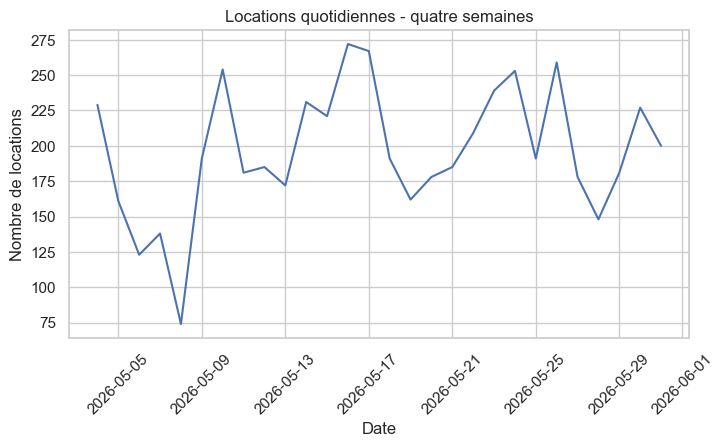

In [18]:
plt.figure(figsize=(8, 4))

plt.plot(bike_demo["date"], bike_demo["rentals"])

plt.title("Locations quotidiennes - quatre semaines")
plt.xlabel("Date")   #plt.gcal().set.xlabel("Date")
plt.ylabel("Nombre de locations")

plt.xticks(rotation=45)

plt.grid(visible=True)

plt.show()

Le titre donne la question ; les labels précisent les grandeurs et unités. Les pics deviennent visibles au premier regard.
Une seule courbe clairement nommée n'a pas besoin de légende.

**Je veux voir simultanément les locations et la température.** Une figure peut contenir plusieurs zones de tracé.
Avec `plt.subplots(1, 2)`, `axes[0]` et `axes[1]` sont les deux zones, de gauche à droite.

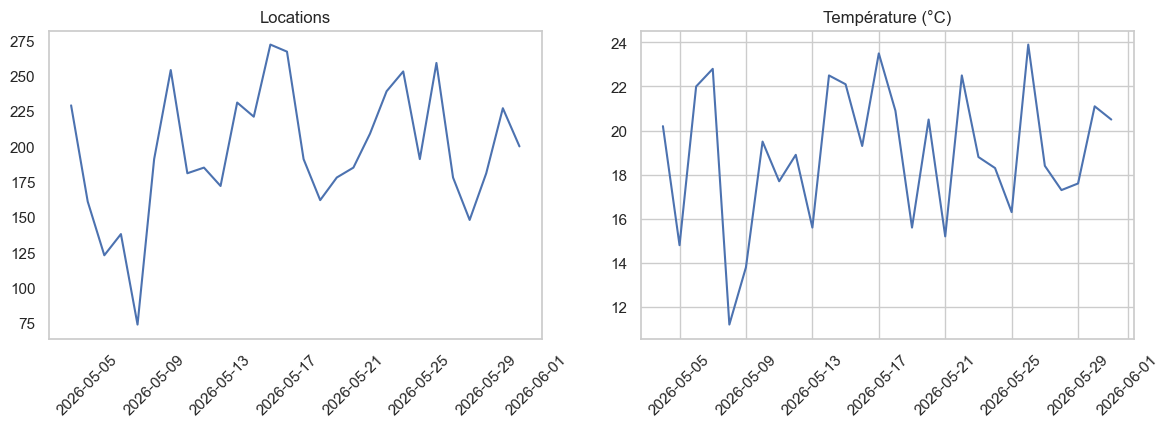

In [19]:
# subplots (une figure qui contient des axes, un ax contient un plot)

# FIGURE -> AX -> PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(bike_demo["date"], bike_demo["rentals"])
axes[0].set_title("Locations")
axes[0].grid()
axes[0].tick_params(axis="x", labelrotation=45)

axes[1].plot(bike_demo["date"], bike_demo["temperature_c"])
axes[1].set_title("Température (°C)")
axes[1].grid(visible=True)
axes[1].tick_params(axis="x", labelrotation=45)

plt.show()

### Exercice A — ventes mensuelles · 15 min
**SOCLE.** Passer du jour au mois et choisir une représentation temporelle.
La préparation est fournie : `monthly_sales` contient un montant total par mois, dans l'ordre chronologique.
Les totaux utilisent **toutes** les lignes de `sales`.

In [20]:
# transform en Period (tranche de temps), puis re en datetime (on ne garde que l'info de la semaine du coup)
sales["month"] = sales["invoice_date"].dt.to_period("W").dt.to_timestamp()

# "named aggregation" : rename la colonne sur le tas ! (très pratique)
monthly_sales = sales.groupby("month", as_index=False).agg(
    total_sales_gbp=("line_total_gbp", "sum"),
)
monthly_sales = monthly_sales.sort_values("month")
monthly_sales

,month,total_sales_gbp
0,2010-01-04,168228.580
1,2010-01-11,163595.570
2,2010-01-18,153725.871
3,2010-01-25,165605.091
4,2010-02-01,124084.092
5,2010-02-08,90814.120
6,2010-02-15,174496.562
7,2010-02-22,162109.952
8,2010-03-01,165865.590
9,2010-03-08,141839.540


**A — Représenter**

Comment le montant total des ventes évolue-t-il au cours des mois disponibles ? Choisissez une représentation adaptée et produisez-la avec Matplotlib, avec un titre et des axes nommés.

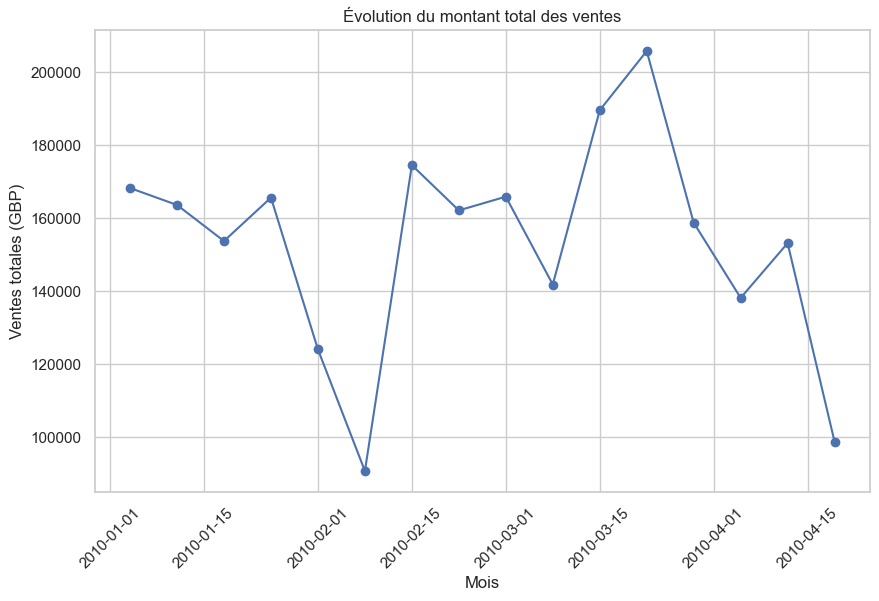

In [28]:
# TODO montrons Comment le montant total des ventes évolue-t-il au cours des mois disponibles ?
#  Choisissez une représentation adaptée et produisez-la avec Matplotlib, avec un titre et des axes nommés.

plt.figure(figsize=(10, 6))
plt.plot(
    monthly_sales["month"],
    monthly_sales["total_sales_gbp"],
    marker="o"
)
plt.title("Évolution du montant total des ventes")
plt.xlabel("Mois")
plt.ylabel("Ventes totales (GBP)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## 2. Distributions et comparaisons · 9h40–10h20
**Quelle représentation choisir pour comprendre une distribution ou comparer des groupes ?**

### Démonstration — histogramme
**Comment se répartit le nombre de locations quotidiennes ?**
`sns.histplot` regroupe les valeurs dans des intervalles (*bins*). La hauteur compte les jours dans chaque intervalle.
On lit la concentration, l'étendue et une éventuelle asymétrie.

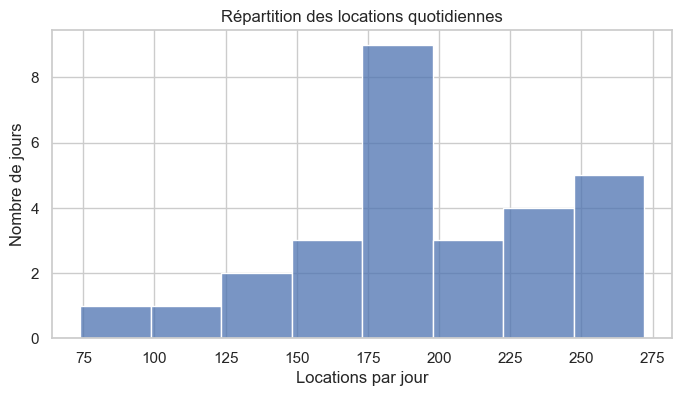

In [29]:
plt.figure(figsize=(8, 4))

sns.histplot(data=bike_demo, x="rentals", bins=8)

plt.title('Répartition des locations quotidiennes')
plt.xlabel('Locations par jour')
plt.ylabel('Nombre de jours')

plt.show()

### Démonstration — boxplot
**Les locations ont-elles le même profil le week-end et en semaine ?**

`sns.boxplot` compare une mesure quantitative entre catégories.
Le trait dans la boîte représente la **médiane** ; la boîte va de **Q1 à Q3** (les 50 % centraux).
Les moustaches atteignent les observations dans la limite de 1,5 fois l'écart interquartile autour de la boîte.
Les points au-delà sont des valeurs éloignées selon cette règle, pas nécessairement des erreurs.

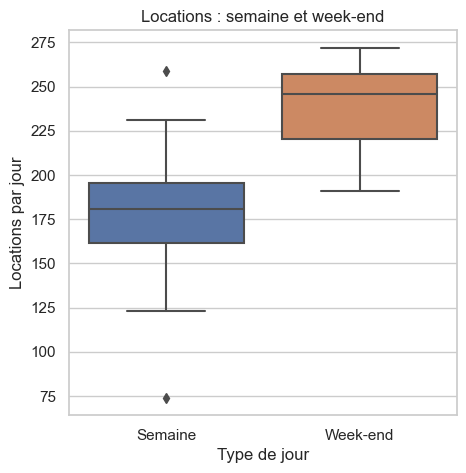

In [30]:
plt.figure(figsize=(5, 5))

sns.boxplot(
    data=bike_demo, x="weekend", y="rentals",
    order=["Semaine", "Week-end"],
    #orient='h' # attention à inverser x et y également ...
)

plt.title('Locations : semaine et week-end')
plt.xlabel('Type de jour')
plt.ylabel('Locations par jour')

plt.show()

Le week-end présente ici une médiane plus élevée ; les boîtes décrivent la dispersion centrale.
Il y a 20 jours de semaine et seulement 8 jours de week-end : ces profils sont descriptifs.

### Exercice B — comprendre les montants · 20 min
**SOCLE.** Choisir le graphique avant de le coder ; interpréter après l'avoir affiché.

**Vue de visualisation fournie.** Quelques lignes de vente atteignent 10 953,50 GBP et écrasent l'échelle.
Pour rendre la zone principale de la distribution lisible, on effectue ici un zoom visuel sur les 99 % de valeurs les plus basses.
Les données originales ne sont pas supprimées de `sales`.

`sales_viz` sert aux distributions ; `sales` reste la référence pour les totaux.
Le seuil est global : chaque pays peut perdre une proportion différente de lignes dans cette vue.

Les boxplots permettent de montrer la répartition de points des données avec les moustaches et les quartiles en fonction de leur placement. Les points loins des quartiles sont souvent outliers 

In [50]:
limit = sales["line_total_gbp"].quantile(0.95)

sales_viz = sales[
    sales["line_total_gbp"] <= limit
].copy()

print(f"Zoom : montant de ligne ≤ {limit:.2f} GBP")

Zoom : montant de ligne ≤ 63.50 GBP


**B.1 — Répartition**

Vous voulez comprendre la répartition des montants des ventes. Quel graphique choisissez-vous, et que montre-t-il ? Utilisez `sales_viz` et signalez le zoom dans le titre.

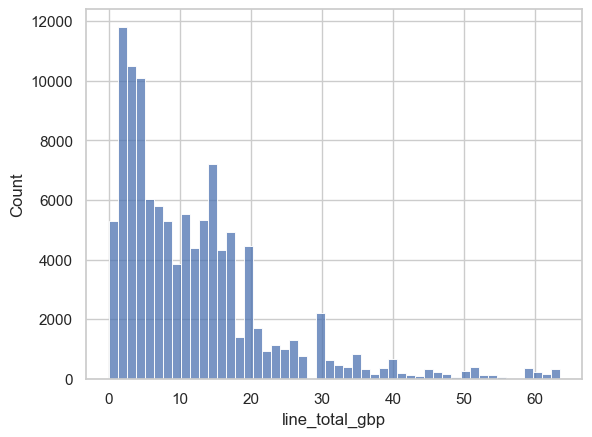

In [51]:
# TODO B1 nous voulons  comprendre la répartition des montants des ventes. 
# Quel graphique choisissez-vous, et que montre-t-il ? 
# Utilisez `sales_viz` et signalez le zoom dans le titre.
plt.Figure(figsize=(8, 4))

sns.histplot(data=sales_viz, x="line_total_gbp", bins=50);

**B.2 — Interprétation**

La distribution paraît-elle symétrique ? Où se concentre la majorité des observations ?

In [52]:
# TODO B2 La distribution paraît-elle symétrique ? 
# Où se concentre la majorité des observations ?
top_countries = sales["country"].value_counts().head(4).index.tolist()

country_viz = sales_viz[
    sales_viz["country"].isin(top_countries)
].copy()

top_countries

['United Kingdom', 'Germany', 'EIRE', 'France']

**Préparation fournie pour la comparaison.** Les quatre pays sont choisis selon leur nombre de lignes dans `sales`, puis observés dans la même vue de zoom.

In [53]:
top_countries = sales["country"].value_counts().head(4).index.tolist()

country_viz = sales_viz[
    sales_viz["country"].isin(top_countries)
].copy()

top_countries

['United Kingdom', 'Germany', 'EIRE', 'France']

**B.3 — Comparaison**

Vous voulez comparer la dispersion des montants des lignes de vente entre les quatre pays les plus représentés. Quel graphique est adapté ? Utilisez `country_viz`.

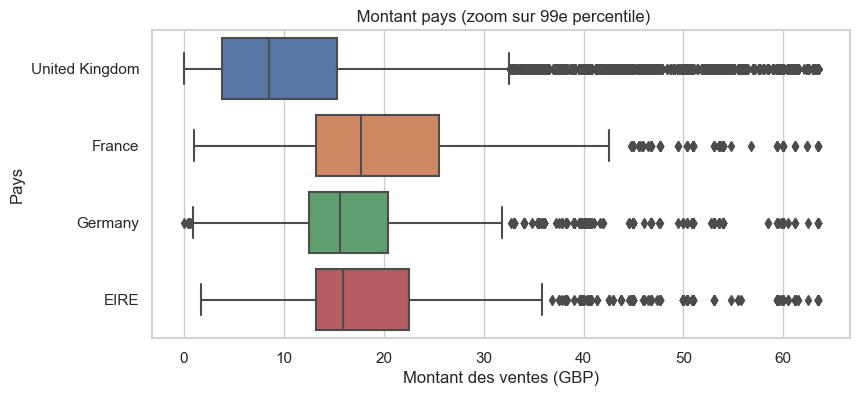

In [54]:
# TODO B3
plt.figure(figsize=(9, 4))
sns.boxplot(
    data=country_viz, y="country", x="line_total_gbp",
)
plt.title(" Montant pays (zoom sur 99e percentile)")
plt.xlabel('Montant des ventes (GBP)')
plt.ylabel('Pays')

plt.show()


**B.4 — Lecture comparée**

Quel pays semble présenter la plus forte dispersion ? Voyez-vous des valeurs extrêmes visibles ? Précisez si vous comparez les boîtes ou les valeurs éloignées.

In [ ]:
# TODO B4 france et ireland ont des bvoîtes identiques plus larges
#Ireland présente des valeurs éloignés plus étalées que France
#Des ppoints éloignés restent visibles dans les quatres pays malgré le zoom
#Le RU a une médiane plus basse; ses nombreux points reflèent aussi son effectif}



## Pause · 10h20–10h35

## 3. Relations entre variables · 10h35–11h20
**Comment passer d'une variable à l'exploration des relations entre plusieurs variables ?**

### Démonstration — scatterplot · 10h35–10h39
**Quand la température augmente, le nombre de locations semble-t-il évoluer ?**
`sns.scatterplot` place un point par observation, avec deux mesures quantitatives.
On regarde la direction générale, la dispersion et d'éventuels groupes.

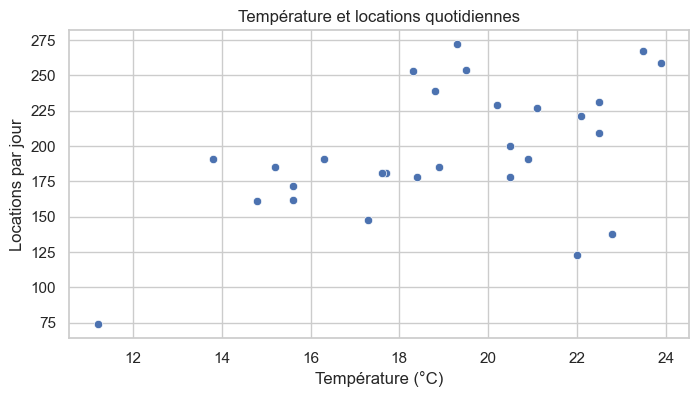

In [55]:
plt.figure(figsize=(8, 4))

sns.scatterplot(data=bike_demo, x="temperature_c", y="rentals") #regplot ?

plt.title('Température et locations quotidiennes')
plt.xlabel('Température (°C)')
plt.ylabel('Locations par jour')

plt.show()

Une tendance croissante reste dispersée : la température seule ne décrit pas toute la variation des locations.
**Observation ≠ preuve ; corrélation ≠ causalité.** Ici, les données sont simulées pour apprendre à lire un graphique.

### Démonstration — Illustrer une matrice de corrélation
**Quelles mesures semblent évoluer ensemble ?**
On sélectionne explicitement les variables quantitatives, puis on calcule leurs corrélations.
Une corrélation résume une **relation linéaire**

In [56]:
numeric_cols = ["temperature_c", "wind_kmh", "rentals", "avg_trip_min"]

corr = bike_demo[numeric_cols].corr()
corr.round(2)

,temperature_c,wind_kmh,rentals,avg_trip_min
temperature_c,1.00,0.13,0.51,0.29
wind_kmh,0.13,1.00,-0.37,0.00
rentals,0.51,-0.37,1.00,0.52
avg_trip_min,0.29,0.00,0.52,1.00


Le coefficient température/locations est **positif** : les deux mesures tendent à augmenter ensemble.
Plus la valeur absolue est proche de 1, plus la relation linéaire est marquée ; le signe indique sa direction.

La diagonale vaut 1 (chaque mesure avec elle-même) ; la matrice est symétrique (A avec B = B avec A).

**La heatmap visualise cette matrice déjà comprise.** L'échelle commune de −1 à +1 permet de lire le signe et l'intensité.

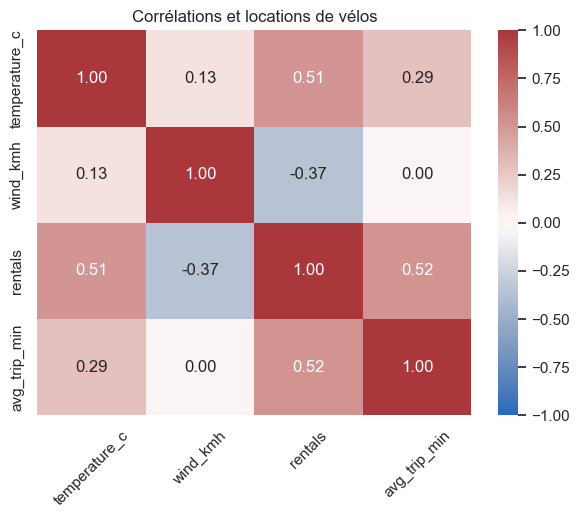

In [57]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr, annot=True, fmt=".2f",
    vmin=-1, vmax=1, center=0, cmap="vlag", #coolwarm
)

plt.title("Corrélations et locations de vélos")
plt.xticks(rotation=45)

plt.show()

### Démonstration — pairplot
**Quelles relations mériteraient ensuite une vue ciblée ?**
`sns.pairplot` sert à naviguer entre plusieurs variables, pas à commenter toutes les cases.
- Diagonale : distribution de chaque variable.
- Hors diagonale : relations deux à deux.
- La couleur permet de repérer des groupes connus.

Repérez un seul motif intéressant. La légende est utile ici pour distinguer semaine et week-end.

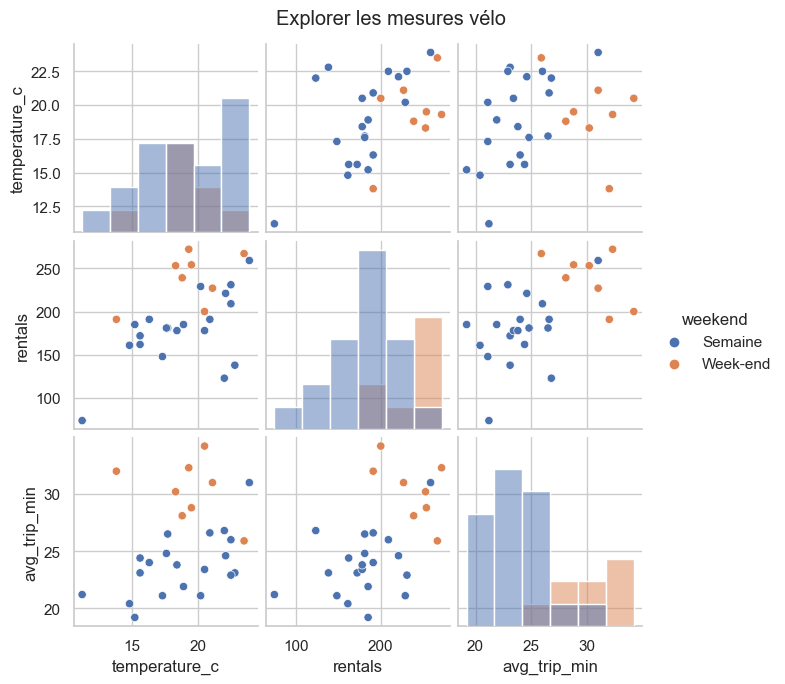

In [58]:
bike_pairs = sns.pairplot(
    bike_demo,
    vars= ["temperature_c", "rentals", "avg_trip_min"],
    hue="weekend",
    diag_kind="hist",
    height=2.2,
)

# ajoute un titre à la figure globale (chaque graph du pairplot est un axe donc plt.title() ne marchera pas -> affecte gca() 'get current axe')
bike_pairs.figure.suptitle("Explorer les mesures vélo", y=1.03)
plt.show()

### Exercice C — morphologie des Penguins · 20 min
**SOCLE.** Une question de relation, puis une vue synthétique, puis une exploration ouverte.
Données : `penguins` 🐧

**C.1 — Deux mesures**

Les manchots ayant des nageoires plus longues ont-ils tendance à être plus lourds ? Choisissez et tracez une représentation à partir de `flipper_length_mm` et `body_mass_g`.

<>:6: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
<>:6: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
C:\Users\hp\AppData\Local\Temp\ipykernel_17176\718409303.py:6: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
  plt.xlabel('longueur de nageoire '(mm))


NameError: name 'mm' is not defined

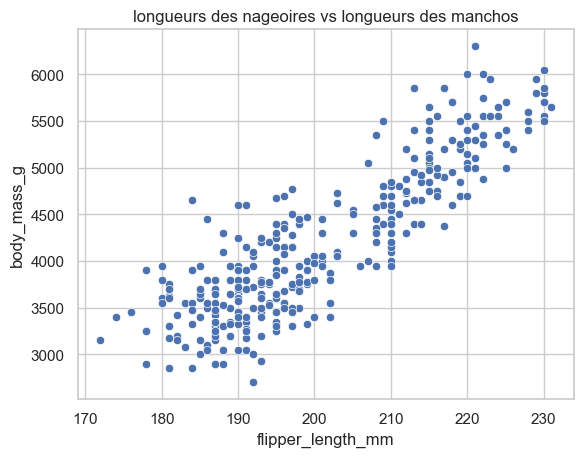

In [61]:
# TODO C1 Les manchots ayant des nageoires plus longues ont-ils tendance à être plus lourds ? 
# Choisissez et tracez une représentation à partir de `flipper_length_mm` et `body_mass_g`.

sns.scatterplot(penguins, x='flipper_length_mm', y="body_mass_g")
plt.title('longueurs des nageoires vs longueurs des manchos')
plt.xlabel("Longueur de nageoire (mm)")
plt.ylabel('Masse corporelle (g)')

plt.show()



**C.2 — Interpréter**

Que semble montrer le nuage de points ? La relation paraît-elle inexistante, faible ou nette ? Voyez-vous des groupes ?

In [ ]:
# TODO C2 Relation positive nette; les nageoires longues vont souvent avec une masse élevée
#le nuage suggère plusieurs groupes ? male/femelle 


**C.3 — Vue synthétique**

Vous voulez maintenant savoir quelles mesures morphologiques semblent le plus évoluer ensemble. Quelle représentation permet d’en avoir une vue synthétique ? Sélectionnez les quatre mesures quantitatives, calculez et affichez leur matrice de corrélation, puis représentez-la.

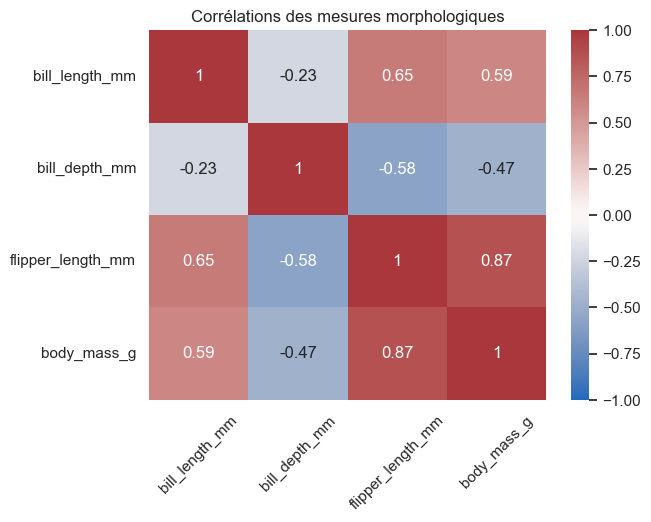

In [63]:
# TODO C3
penguin_corr = penguins[penguins_numeric].corr()

sns.heatmap(
    penguin_corr,
    annot=True,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
);
plt. title("Corrélations des mesures morphologiques")
plt.xticks(rotation=45) ;


**C.4 — Lire sans surinterpréter**

Identifiez la corrélation la plus forte et la correlation la moins marquée.

In [ ]:
# TODO C4


**C.5 — Explorer**

Sans choisir à l’avance une seule paire de variables, comment explorer rapidement toutes les relations entre les quatre mesures quantitatives et repérer d’éventuels groupes d’espèces ? Utilisez la couleur pour distinguer `species`.

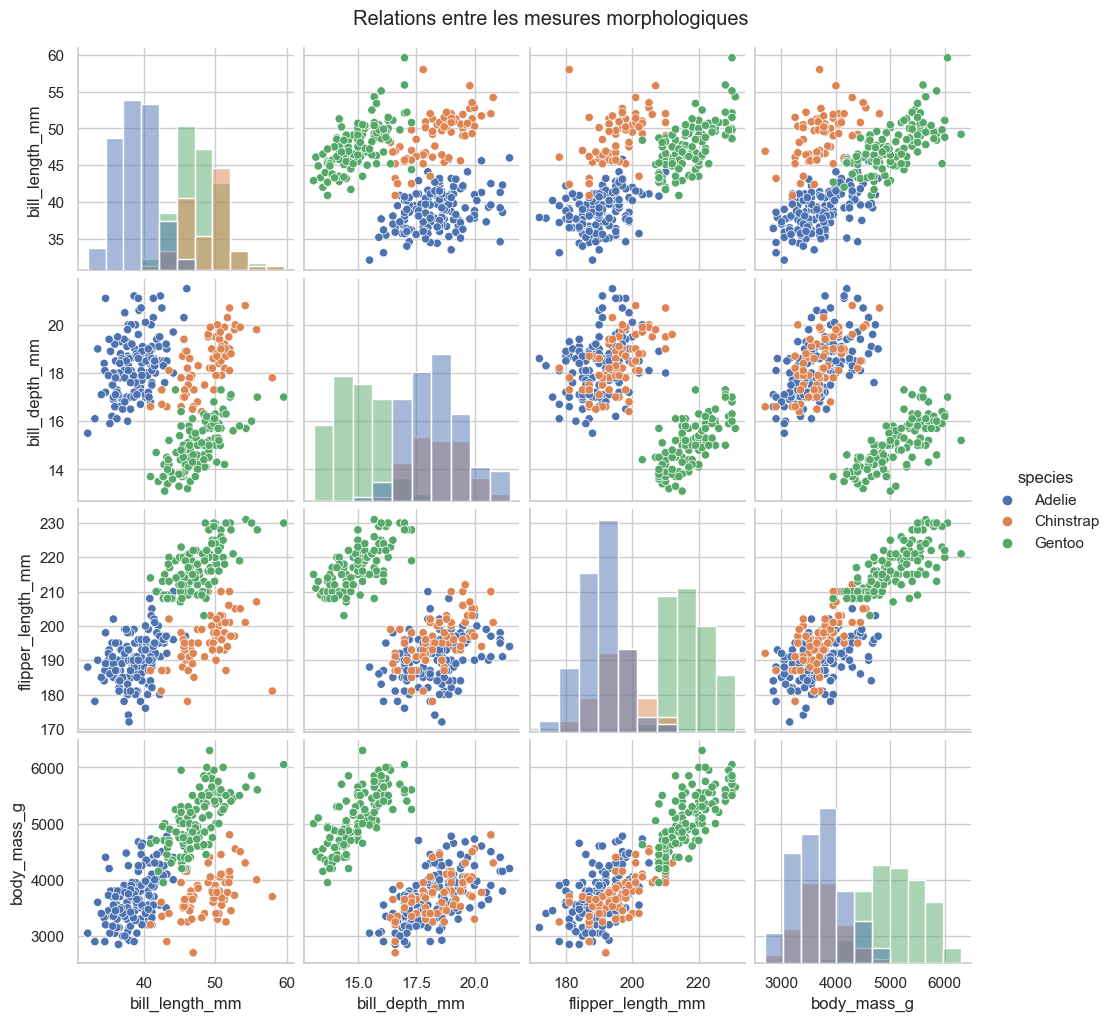

In [68]:
# TODO C5
# TODO C5
penguins_pairs = sns.pairplot(
    data=penguins,
    vars=penguins_numeric,
    hue="species",
    diag_kind="hist",
)

penguins_pairs.figure.suptitle(
    "Relations entre les mesures morphologiques",
    y=1.02,
)

plt.show()



**C.6 — Retablir la vérité**

Pensez-vous toujours que la profondeur du bec `bill_depth_mm` est corrélée négativement avec les autres caractéristiques morphologies (au sein d'une espère donnée) ?

Text(0, 0.5, 'Masse corporelle (g)')

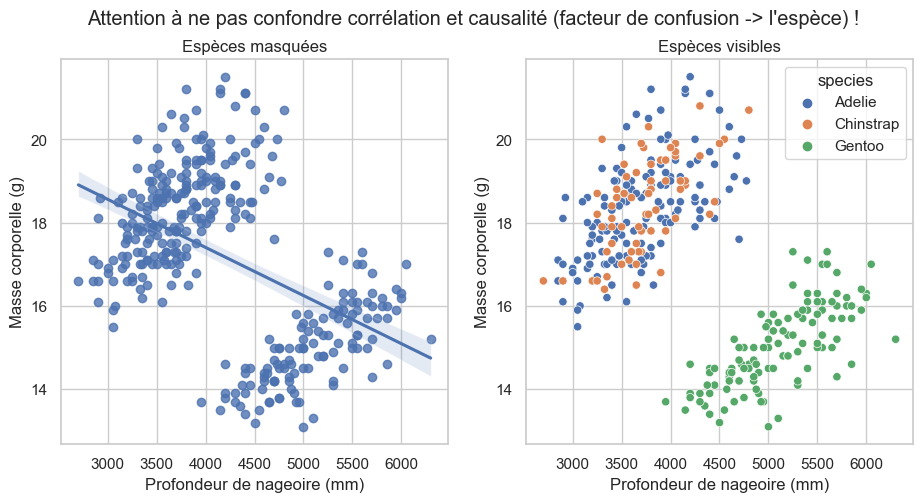

In [69]:
# TODO C6
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
 
fig.suptitle("Attention à ne pas confondre corrélation et causalité (facteur de confusion -> l'espèce) !")
 
sns.regplot(data=penguins, x="body_mass_g", y="bill_depth_mm", ax=axes[0])
axes[0].set_title("Espèces masquées")
axes[0].set_xlabel('Profondeur de nageoire (mm)')
axes[0].set_ylabel('Masse corporelle (g)')
 
sns.scatterplot(data=penguins, x="body_mass_g", y="bill_depth_mm", hue='species', ax=axes[1])
axes[1].set_title("Espèces visibles")
axes[1].set_xlabel('Profondeur de nageoire (mm)')
axes[1].set_ylabel('Masse corporelle (g)')


## 4. TP — Mini-rapport exploratoire des ventes · 40 min
### Mission
Vous devez produire une courte analyse visuelle des ventes destinée à une personne qui ne connaît pas le dataset.

Rédigez comme pour un destinataire métier : unités visibles, périmètre explicite, conclusions mesurées.

**Données disponibles :** `sales`, `sales_viz`, `country_viz`, `top_countries`.
Pour les distributions, signalez le zoom ; pour l'activité totale, repartez de `sales`.

**TP.1 — Ligne de vente typique**

À quoi ressemble une ligne de vente typique ? Explorez la distribution de `line_total_gbp` avec deux vues complémentaires. Vous pouvez les placer côte à côte dans une seule figure ; n’oubliez pas de mentionner le zoom.

Text(0.5, 0, 'Montant de vente (GBP)')

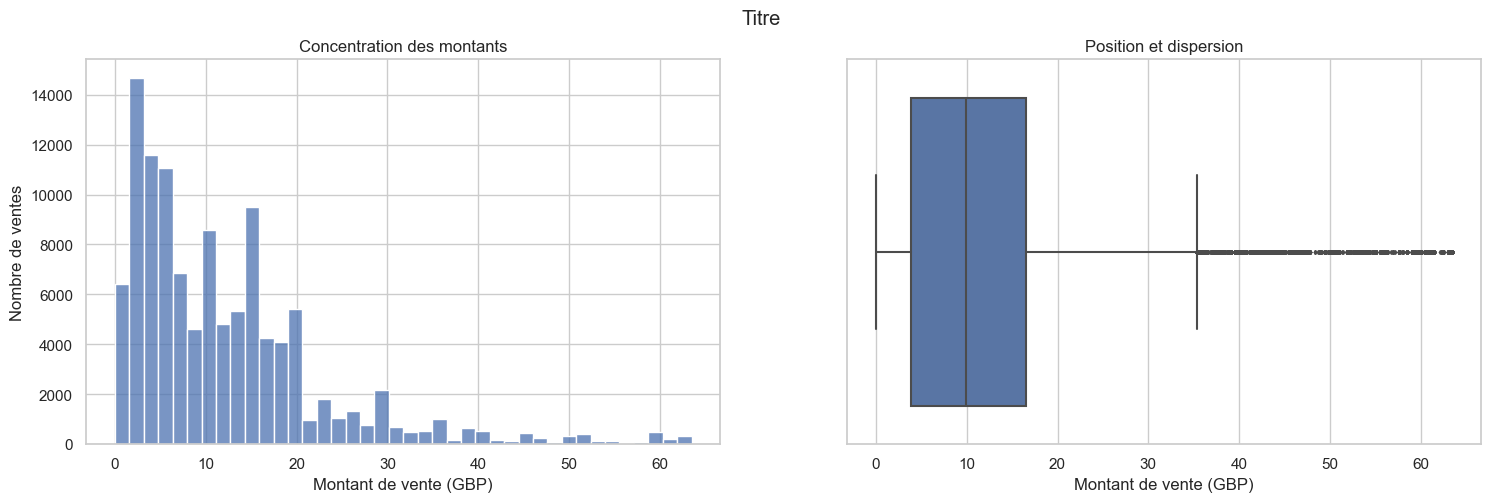

In [70]:
# TODO TP1
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
 
fig.suptitle("Titre")
 
sns.histplot(data=sales_viz, x="line_total_gbp", bins=40, ax=axes[0])
axes[0].set_title("Concentration des montants")
axes[0].set_xlabel("Montant de vente (GBP)")
axes[0].set_ylabel("Nombre de ventes")
 
sns.boxplot(data=sales_viz, x="line_total_gbp", fliersize=2, ax=axes[1])
axes[1].set_title("Position et dispersion")
axes[1].set_xlabel("Montant de vente (GBP)")


**TP.2 — Justifier**

Pourquoi ces représentations sont-elles adaptées ?

In [ ]:
# TODO TP2


**TP.3 — Conclure**

Que constatez-vous sur la concentration, la dispersion et les valeurs extrêmes ?

In [ ]:
# TODO TP3


**BONUS — Correlation intéressante ?**

L'analyse de corrélations ci-dessous est elle pertinente ? Justifiez

In [ ]:
numeric_features = ['quantity', 'unit_price_gbp', 'line_total_gbp']


sales_corr = sales[numeric_features].corr()

sns.heatmap(
    sales_corr, annot=True, fmt=".2f",
    vmin=-1, vmax=1, center=0, cmap="vlag"
)

plt.show()

> VOTRE REPONSE